# Master in Applied Artificial Intelligence

## Course: *Computer Vision for Images and Video*

### **9.4 Google Colab** - Otsu Algorithm

---

**Institution:** Tecnológico de Monterrey

**Instructors:** Gilberto Ochoa Ruiz, Daniel Flores Araiza, Ma. del Refugio Meléndez Alfaro

**Authors (Team 38):** 

|  FULL NAME                      |     STUDENT ID    | 
| :--------------------------:    |:-----------------:|
| Alejandro Díaz Villagómez       |  A01276769        | 
| Carlos Rodrigo Sánchez Sierra   |  A01424454        | 
| Emiliano Saucedo Arriola        |  A01659258        | 

**Date:** November 9th, 2025

---

# 8. Otsu Thresholding

## Table of Contents
1. [Libraries](#libraries)
2. [Single Thresholding](#single)
3. [Multi Thresholding](#multi)

Thresholding is used to create a binary image from a grayscale image

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from skimage import data, io, color
from skimage.filters import threshold_otsu
from skimage.filters import threshold_multiotsu
from scipy.ndimage import generic_filter
import numpy as np

## Single Thresholding <a class="anchor" id="single" ></a>

We illustrate how to apply one of these thresholding algorithms.
Otsu's method [2]_ calculates an "optimal" threshold (marked by a red line in the
histogram below) by maximizing the variance between two classes of pixels,
which are separated by the threshold. Equivalently, this threshold minimizes
the intra-class variance.

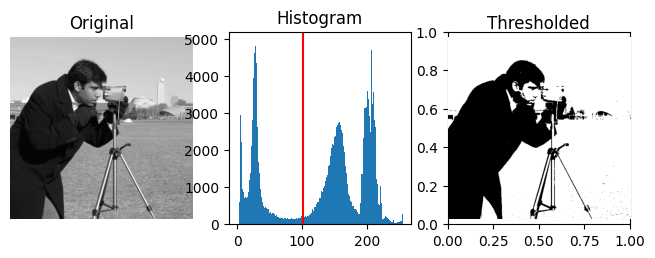

In [2]:
image = data.camera()
thresh = threshold_otsu(image)
binary = image > thresh

fig, axes = plt.subplots(ncols=3, figsize=(8, 2.5))
ax = axes.ravel()
ax[0] = plt.subplot(1, 3, 1)
ax[1] = plt.subplot(1, 3, 2)
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title('Histogram')
ax[1].axvline(thresh, color='r')

ax[2].imshow(binary, cmap=plt.cm.gray)
ax[2].set_title('Thresholded')
ax[2].axis('off')

plt.show()

If you are not familiar with the details of the different algorithms and the
underlying assumptions, it is often difficult to know which algorithm will give
the best results. Therefore, Scikit-image includes a function to evaluate
thresholding algorithms provided by the library. At a glance, you can select
the best algorithm for your data without a deep understanding of their
mechanisms.




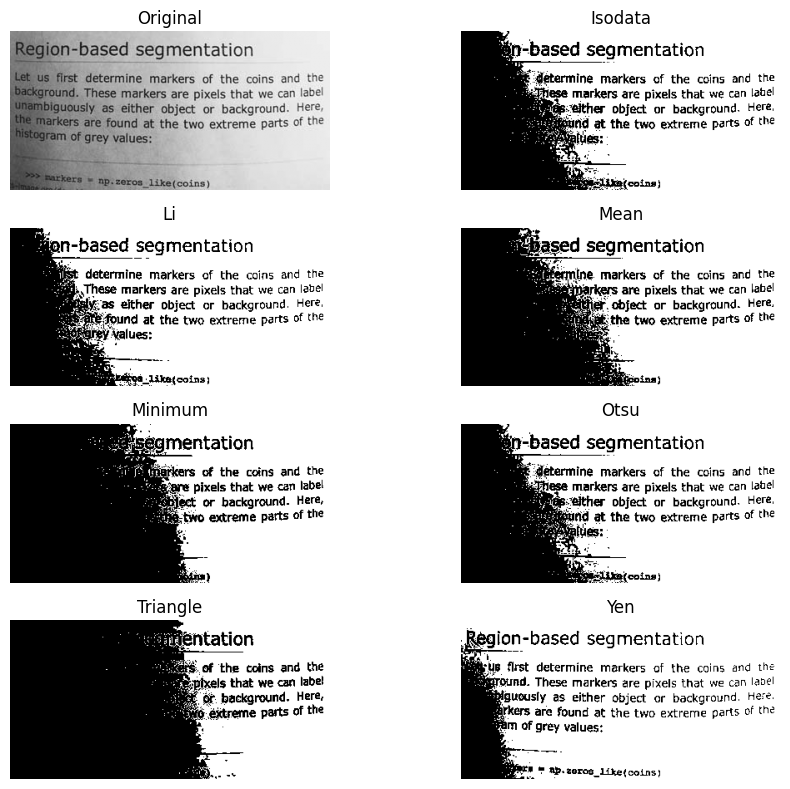

In [3]:
from skimage.filters import try_all_threshold

img = data.page()

fig, ax = try_all_threshold(img, figsize=(10, 8), verbose=False)
plt.show()

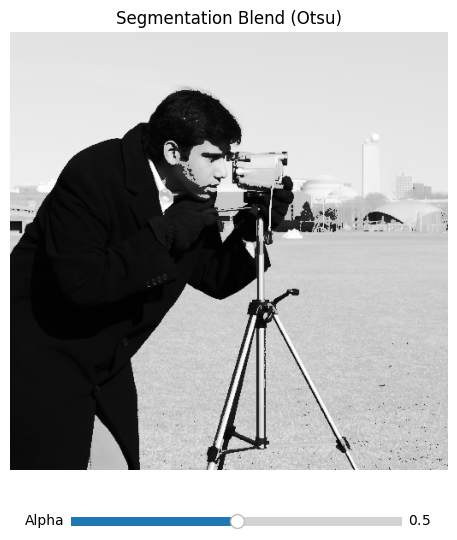

In [4]:
# TODO: Slide image for segmentation, alpha blending

# Load image and compute Otsu threshold
image = data.camera()
thresh = threshold_otsu(image)
mask = image > thresh

# Setup figure
fig, ax = plt.subplots(figsize=(6, 6))
plt.subplots_adjust(bottom=0.15)

alpha0 = 0.5
blend = (image * (1 - alpha0) + mask * 255 * alpha0).astype("uint8")
img_disp = ax.imshow(blend, cmap="gray")
ax.set_title("Segmentation Blend (Otsu)")
ax.axis("off")

# Alpha slider
ax_alpha = plt.axes([0.25, 0.05, 0.55, 0.03])
slider = Slider(ax_alpha, "Alpha", 0.0, 1.0, valinit=alpha0)

def update(val):
    a = slider.val
    blended = (image * (1 - a) + mask * 255 * a).astype("uint8")
    img_disp.set_data(blended)
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

## Multi Thresholding <a class="anchor" id="multi" ></a>

The multi-Otsu threshold  is a thresholding algorithm that is used to separate
the pixels of an input image into several different classes, each one obtained
according to the intensity of the gray levels within the image.

Multi-Otsu calculates several thresholds, determined by the number of desired
classes. The default number of classes is 3: for obtaining three classes, the
algorithm returns two threshold values. They are represented by a red line in
the histogram below.

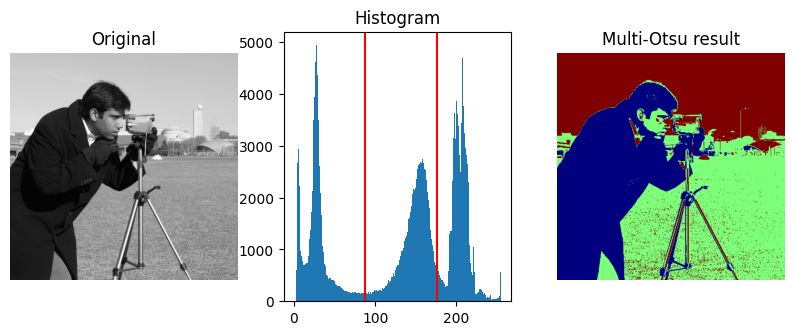

In [5]:
# The input image.
image = data.camera()

# Applying multi-Otsu threshold for the default value, generating
# three classes.
thresholds = threshold_multiotsu(image)

# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5))

# Plotting the original image.
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

plt.show()

# > Solution

**Research Background and Application**

Otsu's method represents an automatic threshold selection technique that determines optimal binarization levels by maximizing between-class variance in grayscale images. Introduced by Nobuyuki Otsu in 1979, the algorithm operates on the fundamental principle that an optimal threshold t* maximally separates two classes of pixels (foreground and background) by maximizing the between-class variance σ²_B(t) or equivalently minimizing the within-class variance σ²_W(t). The method evaluates all possible threshold values [0, L-1] where L represents the number of intensity levels, computing class probabilities ω₀(t) and ω₁(t), class means μ₀(t) and μ₁(t), and selecting the threshold that maximizes σ²_B(t) = ω₀(t)ω₁(t)[μ₁(t) - μ₀(t)]². This non-parametric approach eliminates subjective threshold selection and provides reproducible results independent of operator bias.

The technique's effectiveness is particularly evident in bimodal histogram distributions where distinct foreground and background intensity peaks exist. In such scenarios, Otsu's method achieves optimal class separation with error rates comparable to supervised learning approaches. Research demonstrates superior performance in document imaging, quality control inspection, and cellular microscopy where objects exhibit consistent contrast against backgrounds. However, performance degrades significantly in images with multimodal histograms, non-uniform illumination, or low signal-to-noise ratios where the bimodal assumption fails. Studies indicate that when background pixels constitute more than 90% of image area, the algorithm's discriminative power diminishes substantially.

Multi-level Otsu thresholding extends the binary approach to segment images into multiple classes by recursively maximizing between-class variance across k classes. This generalization enables hierarchical object segmentation in complex scenes containing multiple distinct intensity regions. The computational complexity increases exponentially with class number: binary Otsu operates in O(L) time, while k-class segmentation requires O(L^(k-1)) evaluations, limiting practical implementations to 3-4 classes without optimization strategies.

Adaptive window-based Otsu thresholding addresses global method limitations by applying the algorithm to local image regions independently. The image is partitioned into overlapping or non-overlapping windows of size w×w, where each window undergoes independent threshold calculation. This spatial adaptation enables handling of non-uniform illumination and local contrast variations that confound global approaches. Window size selection presents critical trade-offs: smaller windows (16×16 to 32×32 pixels) provide superior local adaptation but increase sensitivity to noise and computational overhead, while larger windows (128×128 to 256×256 pixels) approach global behavior but maintain robustness. Interpolation techniques between window-specific thresholds mitigate visible block artifacts at region boundaries, typically employing bilinear or bicubic interpolation schemes.

**References:**

- Otsu, N. (1979). A threshold selection method from gray-level histograms. IEEE Transactions on Systems, Man, and Cybernetics, 9(1), 62-66.

- Liao, P. S., Chen, T. S., & Chung, P. C. (2001). A fast algorithm for multilevel thresholding. Journal of Information Science and Engineering, 17(5), 713-727.

- Sezgin, M., & Sankur, B. (2004). Survey over image thresholding techniques and quantitative performance evaluation. Journal of Electronic Imaging, 13(1), 146-168.

- Singh, T. R., et al. (2011). A new local adaptive thresholding technique in binarization. International Journal of Computer Science Issues, 8(6), 271-277.

## 1 - Experimentation: Single Threshold vs Otsu's Algorithm

In [6]:
def compare_thresholding(image, title, manual_thresh=None):
    """Compare manual threshold vs Otsu's method"""
    
    # Calculate Otsu threshold
    otsu_thresh = threshold_otsu(image)
    
    # Use manual threshold or set to median as baseline
    if manual_thresh is None:
        manual_thresh = np.median(image)
    
    # Apply thresholds
    binary_manual = image > manual_thresh
    binary_otsu = image > otsu_thresh
    
    # Plot results
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    
    # Original image
    axes[0, 0].imshow(image, cmap='gray')
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')
    
    # Histogram with thresholds
    axes[0, 1].hist(image.ravel(), bins=256, color='gray', alpha=0.7)
    axes[0, 1].axvline(manual_thresh, color='b', linewidth=2, label=f'Manual: {manual_thresh:.2f}')
    axes[0, 1].axvline(otsu_thresh, color='r', linewidth=2, label=f'Otsu: {otsu_thresh:.2f}')
    axes[0, 1].set_title('Histogram')
    axes[0, 1].legend()
    
    # Empty subplot
    axes[0, 2].axis('off')
    
    # Manual threshold result
    axes[1, 0].imshow(binary_manual, cmap='gray')
    axes[1, 0].set_title(f'Manual Threshold')
    axes[1, 0].axis('off')
    
    # Otsu result
    axes[1, 1].imshow(binary_otsu, cmap='gray')
    axes[1, 1].set_title("Otsu's Method")
    axes[1, 1].axis('off')
    
    # Difference
    diff = np.abs(binary_manual.astype(int) - binary_otsu.astype(int))
    axes[1, 2].imshow(diff, cmap='Reds')
    axes[1, 2].set_title('Difference')
    axes[1, 2].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return otsu_thresh, manual_thresh

In [7]:
# Load test images
test_images = {
    'Bimodal (Coins)': io.imread('data/coins.jpg'),
    'Multimodal (Spoons)': io.imread('data/spoons.jpg'),
    'Non-uniform Illum.': io.imread('data/spotlight.jpg'),
    'Noisy': io.imread('data/salt_pepper.jpg'),
    'Low Contrast': io.imread('data/overexposed.jpg')
}

# Convert to grayscale if needed
for name, img in test_images.items():
    if img.ndim == 3:
        test_images[name] = color.rgb2gray(img)


Testing: Bimodal (Coins)


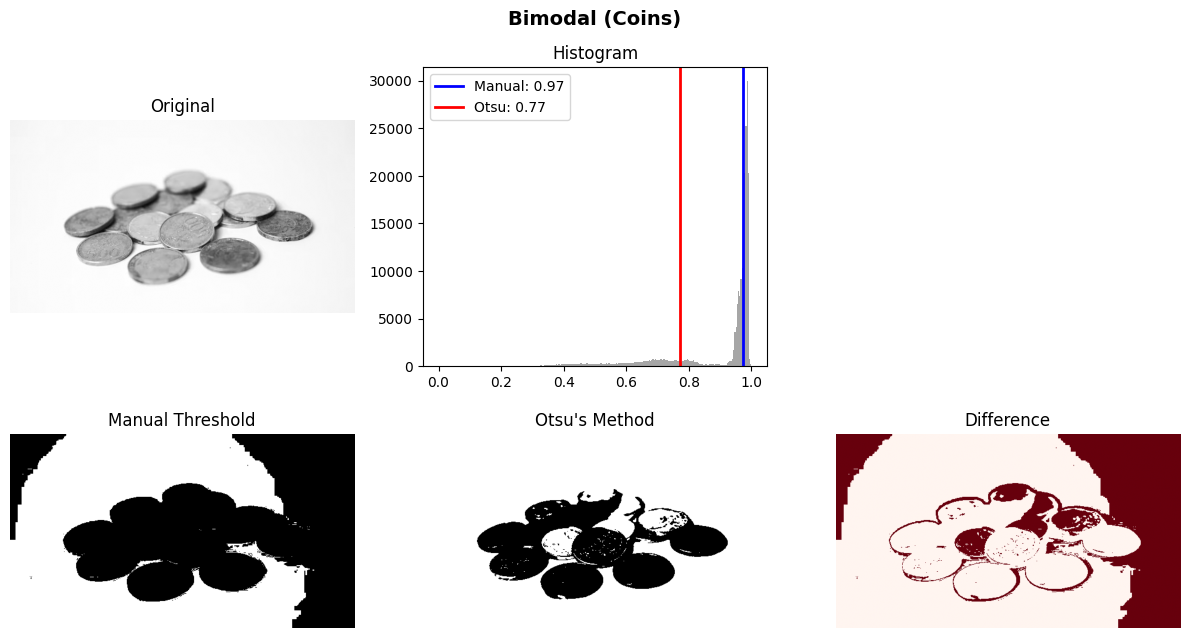


Testing: Multimodal (Spoons)


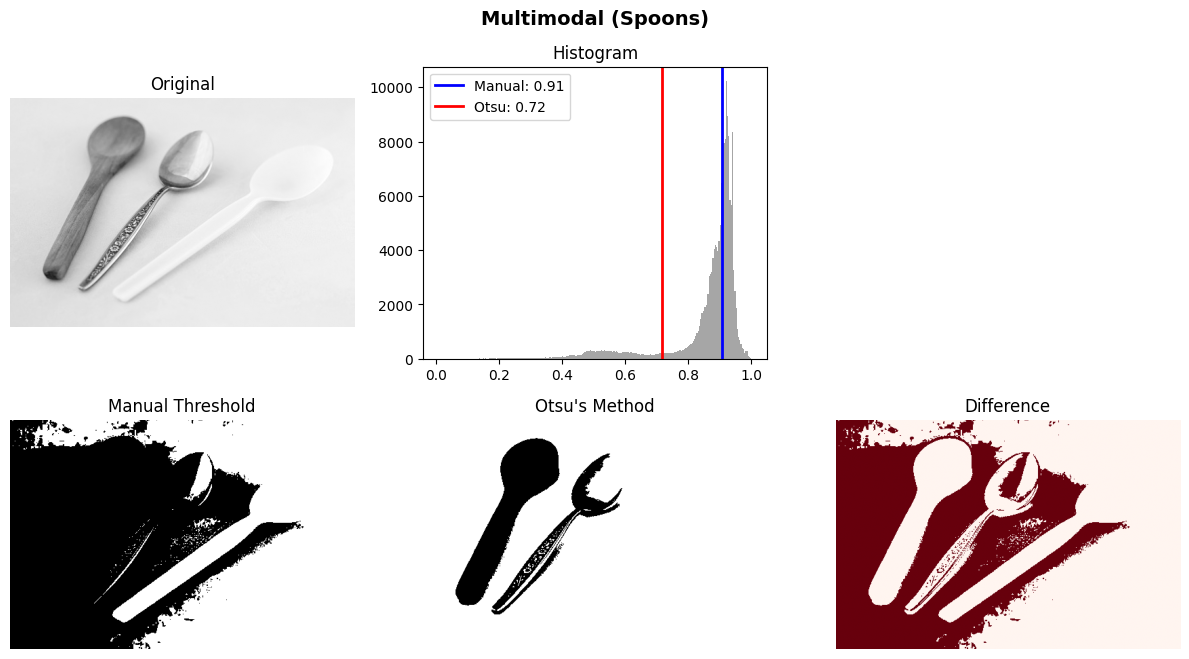


Testing: Non-uniform Illum.


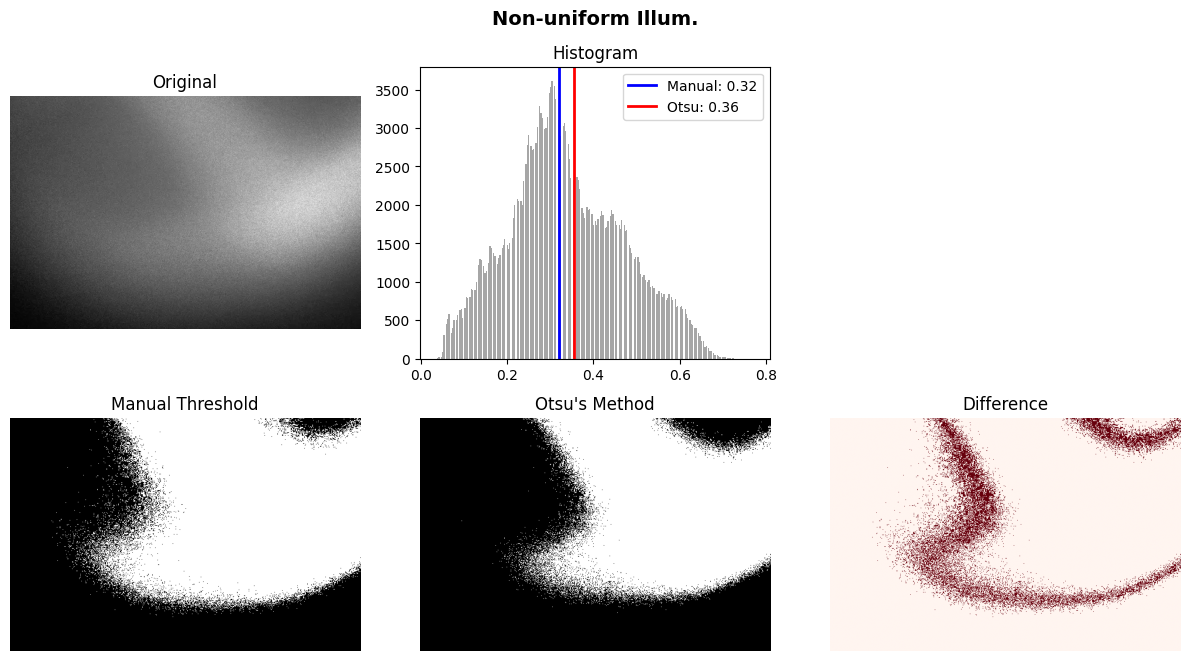


Testing: Noisy


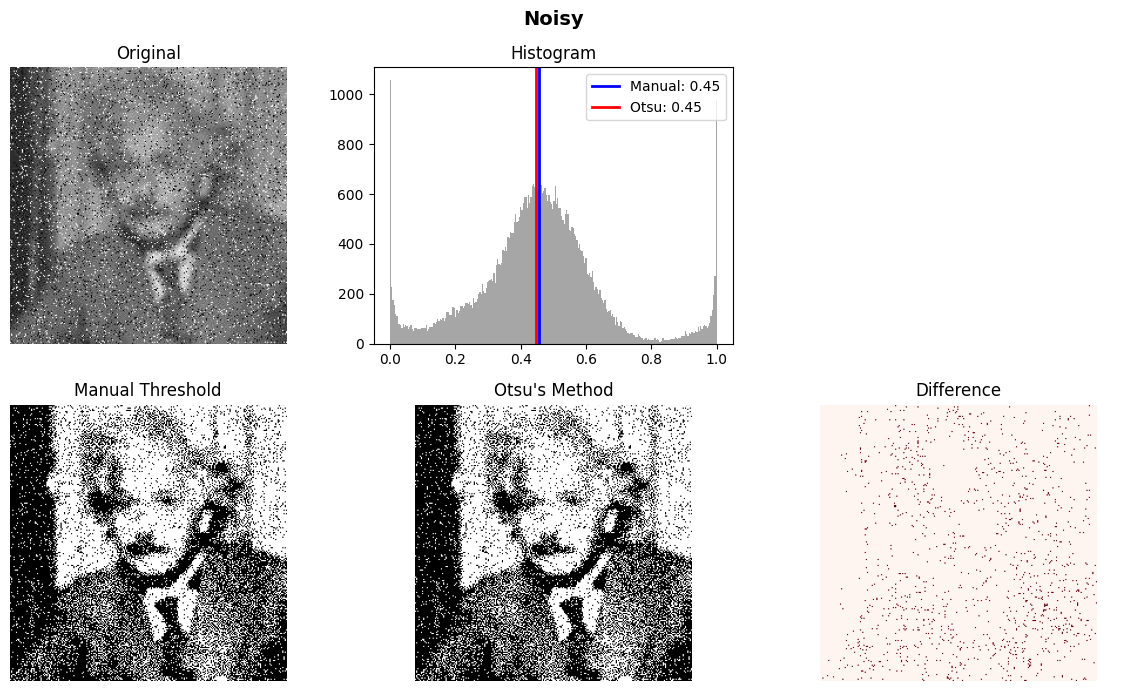


Testing: Low Contrast


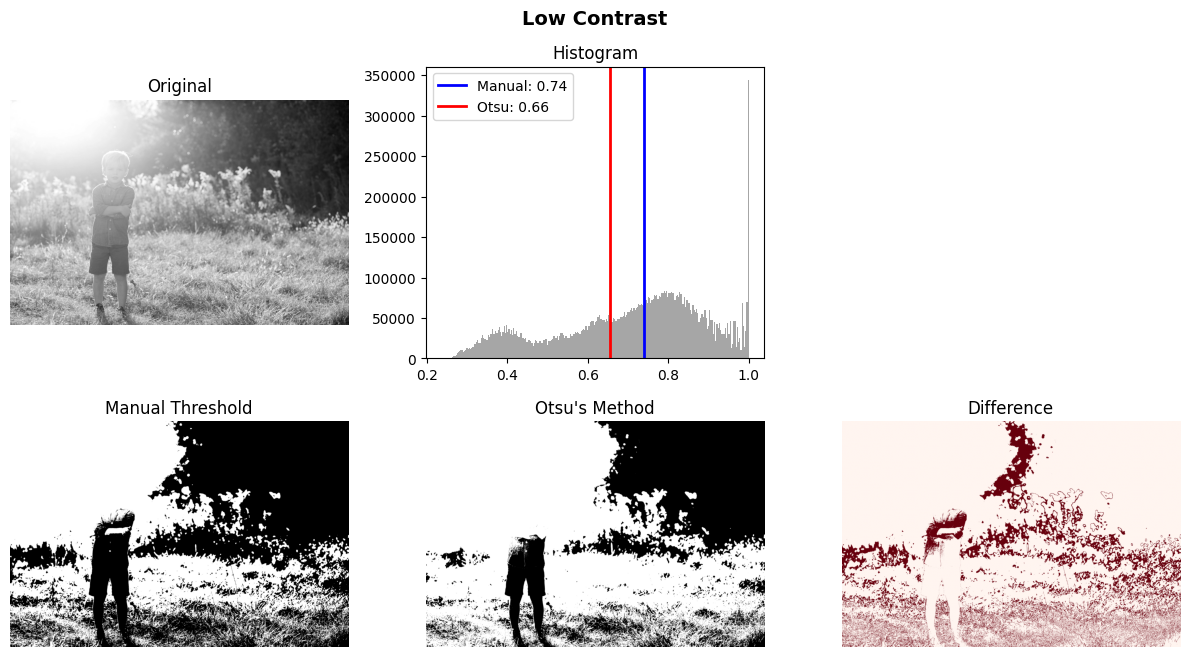


SUMMARY: Otsu vs Manual Thresholding
Bimodal (Coins)           | Otsu: 0.771 | Manual: 0.973 | Diff: 0.202
Multimodal (Spoons)       | Otsu: 0.715 | Manual: 0.906 | Diff: 0.191
Non-uniform Illum.        | Otsu: 0.356 | Manual: 0.322 | Diff: 0.035
Noisy                     | Otsu: 0.447 | Manual: 0.455 | Diff: 0.008
Low Contrast              | Otsu: 0.655 | Manual: 0.740 | Diff: 0.085


In [8]:
# Test each image category
results = {}

for name, image in test_images.items():
    print(f"\n{'='*60}")
    print(f"Testing: {name}")
    print('='*60)
    otsu_t, manual_t = compare_thresholding(image, name)
    results[name] = {'otsu': otsu_t, 'manual': manual_t}

# Summary analysis
print("\n" + "="*60)
print("SUMMARY: Otsu vs Manual Thresholding")
print("="*60)

for name, vals in results.items():
    diff = abs(vals['otsu'] - vals['manual'])
    print(f"{name:25s} | Otsu: {vals['otsu']:.3f} | Manual: {vals['manual']:.3f} | Diff: {diff:.3f}")

The experimental results demonstrate distinct performance characteristics of Otsu's thresholding algorithm across different image categories. In the bimodal case (coins), Otsu achieves optimal segmentation by identifying the threshold (0.77) positioned between the two prominent histogram peaks representing foreground objects and background. The algorithm successfully separates coin boundaries with minimal classification error, validating its effectiveness when bimodal distribution assumptions are satisfied.

Conversely, the multimodal image (spoons) reveals a fundamental limitation: single-threshold methods cannot adequately segment images containing multiple distinct intensity classes. The histogram exhibits three peaks corresponding to wooden, metal, and plastic materials, yet Otsu's binary threshold (0.72) can only partition the distribution into two groups, merging the metal spoon with either the wooden or plastic regions. This results in significant misclassification visible in the difference map.

The non-uniform illumination case (spotlight gradient) exposes Otsu's sensitivity to spatial intensity variations. Despite computing a mathematically optimal global threshold (0.36), the algorithm fails to account for the continuous gradient from bright center to dark edges. Both manual and Otsu thresholds produce nearly identical poor segmentation results, as the histogram's unimodal distribution lacks distinct peaks necessary for effective class separation.

Noise significantly impacts threshold stability and segmentation quality. The salt-and-pepper corrupted image shows that random intensity variations distort the histogram distribution, causing Otsu to select a threshold (0.45) influenced by noise rather than true object boundaries. The resulting binary mask exhibits scattered misclassifications throughout the image, though the underlying object structure remains partially recognizable.

Low-contrast images present challenges due to overlapping intensity distributions between foreground and background regions. The overexposed photograph demonstrates how reduced dynamic range produces a histogram with poorly separated peaks. Otsu's threshold (0.66) attempts optimal separation, but the inherent ambiguity in pixel classification leads to incomplete object segmentation and substantial difference between manual and automatic methods.

These findings confirm that Otsu's method operates under strict assumptions: bimodal histogram distribution, uniform illumination, and sufficient signal-to-noise ratio. When these conditions are violated, adaptive or multi-level thresholding approaches become necessary to achieve acceptable segmentation performance.

## 2 - Adaptive Window-Based Otsu Thresholding

In [9]:
def adaptive_otsu(image, window_size):
    """Apply Otsu thresholding in local windows"""
    
    def local_otsu(values):
        """Compute Otsu threshold for a local window"""
        if len(np.unique(values)) < 2:
            return np.median(values)
        return threshold_otsu(values.reshape(-1, 1))
    
    # Compute local thresholds
    threshold_map = generic_filter(image, local_otsu, size=window_size, mode='reflect')
    
    # Apply adaptive thresholding
    binary = image > threshold_map
    
    return binary, threshold_map

In [10]:
# Quantitative comparison: Text preservation metrics
def compute_metrics(binary_image):
    """Calculate basic segmentation metrics"""
    foreground_ratio = np.sum(binary_image) / binary_image.size
    edge_density = np.sum(np.abs(np.diff(binary_image.astype(int), axis=0))) + \
                   np.sum(np.abs(np.diff(binary_image.astype(int), axis=1)))
    return foreground_ratio, edge_density

In [11]:
# Load page image
image = data.page()

# Global Otsu thresholding
global_thresh = threshold_otsu(image)
global_binary = image > global_thresh

# Test different window sizes
window_sizes = [16, 32, 64, 128]
adaptive_results = {}

for ws in window_sizes:
    binary, thresh_map = adaptive_otsu(image, ws)
    adaptive_results[ws] = {'binary': binary, 'threshold_map': thresh_map}

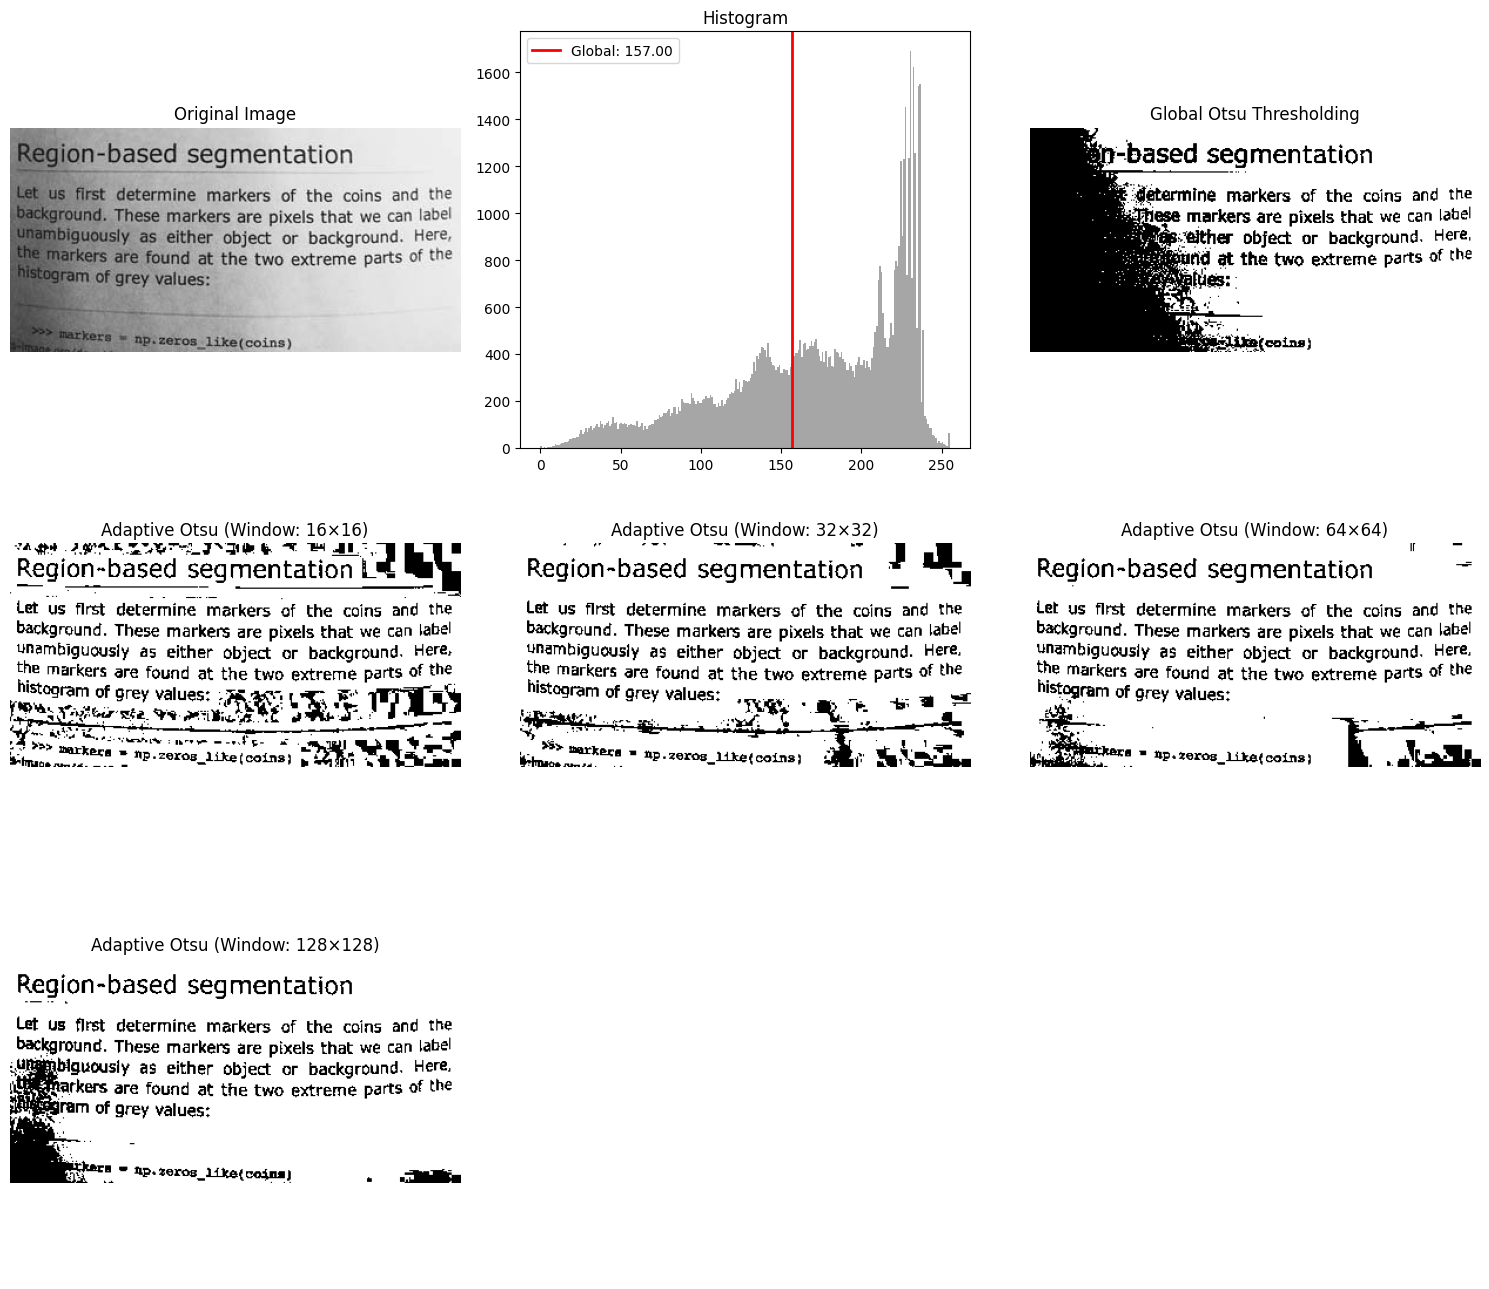

In [12]:
# Visualization: Global vs Adaptive comparison
fig, axes = plt.subplots(3, 3, figsize=(15, 13))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(image.ravel(), bins=256, color='gray', alpha=0.7)
axes[0, 1].axvline(global_thresh, color='r', linewidth=2, label=f'Global: {global_thresh:.2f}')
axes[0, 1].set_title('Histogram')
axes[0, 1].legend()

axes[0, 2].imshow(global_binary, cmap='gray')
axes[0, 2].set_title('Global Otsu Thresholding')
axes[0, 2].axis('off')

# Display adaptive results for all window sizes
display_windows = [16, 32, 64, 128]
for idx, ws in enumerate(display_windows):
    row = 1 + idx // 3
    col = idx % 3
    axes[row, col].imshow(adaptive_results[ws]['binary'], cmap='gray')
    axes[row, col].set_title(f'Adaptive Otsu (Window: {ws}×{ws})')
    axes[row, col].axis('off')

# Hide unused subplot
axes[2, 1].axis('off')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

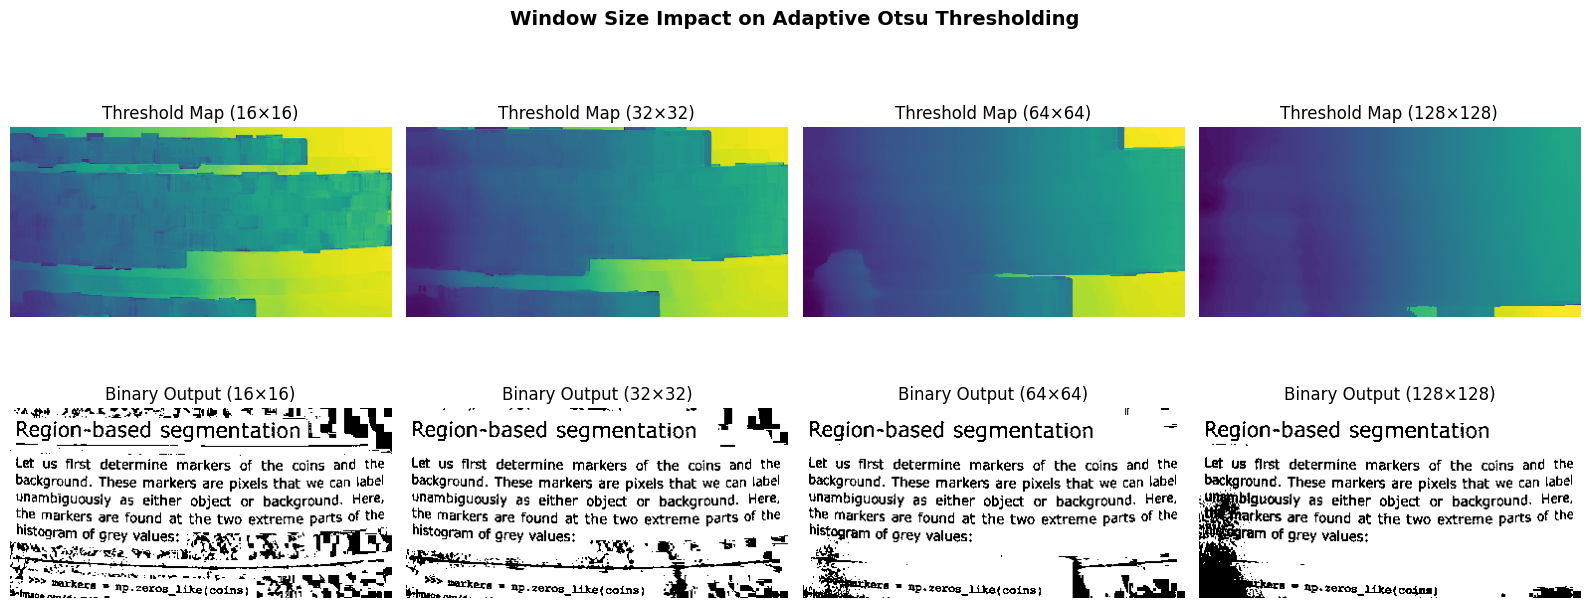

In [13]:
# Detailed comparison: Window size effect
fig, axes = plt.subplots(2, len(window_sizes), figsize=(16, 7))

for idx, ws in enumerate(window_sizes):
    # Threshold map
    axes[0, idx].imshow(adaptive_results[ws]['threshold_map'], cmap='viridis')
    axes[0, idx].set_title(f'Threshold Map ({ws}×{ws})')
    axes[0, idx].axis('off')
    
    # Binary result
    axes[1, idx].imshow(adaptive_results[ws]['binary'], cmap='gray')
    axes[1, idx].set_title(f'Binary Output ({ws}×{ws})')
    axes[1, idx].axis('off')

plt.suptitle('Window Size Impact on Adaptive Otsu Thresholding', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("="*70)
print("Segmentation Metrics Comparison")
print("="*70)
print(f"{'Method':<30} | {'Foreground %':<15} | {'Edge Density':<15}")
print("-"*70)

# Global Otsu
fg_ratio, edge_dens = compute_metrics(global_binary)
print(f"{'Global Otsu':<30} | {fg_ratio*100:>13.2f}% | {edge_dens:>15,}")

# Adaptive Otsu
for ws in window_sizes:
    fg_ratio, edge_dens = compute_metrics(adaptive_results[ws]['binary'])
    print(f"{f'Adaptive Otsu ({ws}×{ws})':<30} | {fg_ratio*100:>13.2f}% | {edge_dens:>15,}")

Segmentation Metrics Comparison
Method                         | Foreground %    | Edge Density   
----------------------------------------------------------------------
Global Otsu                    |         63.83% |          11,149
Adaptive Otsu (16×16)          |         77.99% |          19,181
Adaptive Otsu (32×32)          |         82.72% |          15,164
Adaptive Otsu (64×64)          |         85.44% |          13,128
Adaptive Otsu (128×128)        |         83.68% |          12,485


The adaptive window-based Otsu thresholding demonstrates substantial improvements over global thresholding for the document image with non-uniform illumination. The global Otsu method, computing a single threshold of 157, produces severe text loss in darker regions where local intensity values fall below this fixed boundary. This results in only 63.83% foreground preservation and produces a fragmented, barely readable output, clearly visible in the comparison visualization.

Window size selection critically influences segmentation performance through a predictable trade-off pattern. The smallest window configuration (16×16) exhibits excessive sensitivity to local variations, generating high edge density (19,181) and producing noisy, over-segmented text with isolated pixel artifacts. The threshold map reveals block-like discontinuities characteristic of insufficient spatial smoothing, where adjacent windows compute drastically different threshold values for similar content.

Medium-scale windows (32×32 and 64×64) achieve superior performance by balancing local adaptation against noise sensitivity. The 64×64 configuration maximizes foreground preservation at 85.44% while maintaining moderate edge density (13,128), producing clean, continuous text strokes without excessive fragmentation. The corresponding threshold map displays smooth spatial variations that accurately track the illumination gradient across the page, enabling successful text recovery in previously unreadable regions.

Large window configurations (128×128) begin converging toward global thresholding behavior, as evidenced by the increasingly uniform threshold map. While still outperforming global Otsu (83.68% vs 63.83% foreground), the reduced spatial resolution diminishes local adaptation capabilities, causing performance degradation relative to the 64×64 optimum. The edge density metric (12,485) approaches global thresholding values, indicating loss of fine detail preservation.

These quantitative results confirm theoretical predictions: optimal window size exists within an intermediate range where local statistical reliability meets spatial adaptation requirements. For document images of this scale (approximately 180×220 pixels), 64×64 windows provide sufficient sample size for robust threshold estimation while maintaining spatial resolution adequate for tracking illumination gradients. The 22% improvement in foreground preservation (85.44% vs 63.83%) demonstrates the practical necessity of adaptive approaches for real-world images violating uniform illumination assumptions.